# Portfolio Replica — EDA & Preprocessing

## Problem

We aim to **replicate a black-box portfolio** (e.g. `HFRXGL`) using only its **observed return series**. The underlying holdings are unknown.

**Possible Approach:** construct a portfolio of **liquid Futures contracts** whose returns track the target via **sparse, regularised regression (Lasso / ElasticNet)** in a rolling framework.

---

## Data Overview

- **Source:** Bloomberg
- **Frequency:** Weekly (end-of-week)
- **Period:** Oct 2007 – Apr 2021 (~700 weeks)
- **Currency:** Local (multi-currency)

### Targets
`HFRXGL`, `MXWO`, `MXWD`, `LEGATRUU`

### Futures Universe

- **Equities:** `ES1`, `NQ1`, `VG1`, `TP1`, `LLL1`
- **Bonds:** `TY1`, `TU2`, `RX1`, `DU1`
- **Commodities:** `GC1`, `CO1`

---

## Objective of This Notebook

Prepare clean, reliable inputs for the replication model:

---

## Workflow


---
### 0 · Imports & Configuration


In [22]:
from plots import *
from utilities import *
import statsmodels.api as sm
import urllib.request
import zipfile
import io
import ssl
import traceback

# ── Configuration ──────────────────────────────────────────────────────────
DATA_PATH      = "Dataset3_PortfolioReplicaStrategy.xlsx"
ANNUAL_FACTOR  = 52

# We add Monster_Index here so it's included in all subsequent EDA plots
TARGETS        = ["HFRXGL", "MXWO", "MXWD", "LEGATRUU", "Monster_Index"]
MAIN_TARGET    = "HFRXGL"

# Define the composition for the next block
MONSTER_COMPOSITION = {
    'HFRXGL': 0.0982,
    'MXWO': 0.4785,
    'MXWD': 0.3774,
    'LEGATRUU': 0.0459
}

FUTURES        = ["RX1", "TY1", "GC1", "CO1", "ES1",
                  "VG1", "NQ1", "LLL1", "TP1", "DU1", "TU2"]

# Visualization
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)

print(f"Setup complete. Main Target: {MAIN_TARGET} | Engineered Target: Monster_Index")

Setup complete. Main Target: HFRXGL | Engineered Target: Monster_Index


---
### 1 · Data Loading


In [23]:
# 1. First, load the data normally
data = pd.read_excel(DATA_PATH, header=0)

# 2. Rename first column to Date and set index
data.rename(columns={data.columns[0]: 'Date'}, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# 3. Strip hidden spaces
data.columns = [str(c).strip() for c in data.columns]

# 4. Clean data to numeric
data = data.apply(pd.to_numeric, errors='coerce').dropna(how='all')

# 5. Calculate Returns (Needed for EDA)
# We calculate returns for all available instruments first
all_returns = data.pct_change().dropna()

# 6. Construct the Monster Index returns
# Using the dictionary we defined in the setup block
all_returns['Monster_Index'] = sum(all_returns[k] * w for k, w in MONSTER_COMPOSITION.items())

# 7. Metadata (Names)
meta = pd.read_excel(DATA_PATH, header=None, skiprows=3, nrows=3)
names_list = meta.iloc[0, 1:].tolist()
tickers_list = [str(t).strip() for t in meta.iloc[2, 1:].tolist()]
variable_info = dict(zip(tickers_list, names_list))

# Add the Monster Index to your variable_info so plots have a nice title
variable_info['Monster_Index'] = "Custom Multi-Asset Monster Index"

print(f" Data & Returns loaded. Monster Index constructed.")
print(f" Observations: {len(all_returns)}")

 Data & Returns loaded. Monster Index constructed.
 Observations: 704


---
## 2 · Data Quality Checks

Before any analysis we need to understand the data's health:

1. **Missing values** — Bloomberg data can have gaps when a market was closed or a series had a delayed start.
2. **Data types** — confirm everything is numeric.
3. **Descriptive statistics** — catch obvious anomalies (negative prices, extreme outliers, zero-variance columns).

In [24]:
# ── 2.1 Data Health Summary ───────────────────────────────────────────────
# Consolidate health checks into one view
health = pd.DataFrame({
    "Dtype": data.dtypes,
    "Missing": data.isnull().sum(),
    "Missing (%)": (data.isnull().sum() / len(data) * 100).round(2)
}).sort_values("Missing", ascending=False)

print("=== Data Health Summary (Issues Only) ===")
# Show only columns that actually have missing values
missing_only = health[health["Missing"] > 0]
if missing_only.empty:
    print("All series are 100% complete. No missing values found.")
else:
    display(missing_only)

# ── 2.2 Descriptive Stats (Levels) ────────────────────────────────────────
# Transposed to accommodate your TARGETS + FUTURES universe (15 columns)
print("\n=== Descriptive Statistics (Price Levels) ===")
display(data.describe().round(2).T)

=== Data Health Summary (Issues Only) ===
All series are 100% complete. No missing values found.

=== Descriptive Statistics (Price Levels) ===


,count,mean,std,min,25%,50%,75%,max
MXWO,705.0,1644.13,443.39,705.35,1293.43,1646.69,1978.83,2944.05
MXWD,705.0,404.15,100.98,176.10,328.79,402.57,478.41,702.99
LEGATRUU,705.0,452.20,47.34,342.25,431.74,456.73,478.19,559.31
HFRXGL,705.0,1210.09,73.97,1021.40,1158.15,1215.20,1254.25,1415.11
RX1,705.0,147.28,19.32,110.20,128.90,148.00,163.24,179.32
TY1,705.0,125.97,6.30,110.52,121.20,126.00,130.34,140.33
GC1,705.0,1317.90,274.48,732.70,1178.00,1283.00,1499.70,2001.20
CO1,705.0,77.02,26.79,19.33,54.27,72.05,105.78,140.67
ES1,705.0,1960.44,770.07,689.50,1314.50,1909.25,2569.75,4132.80
VG1,705.0,3072.17,473.81,1873.00,2753.00,3071.00,3433.00,4476.00



# **Data Exploration**

Let's analyze the potential replication targets to understand their characteristics.



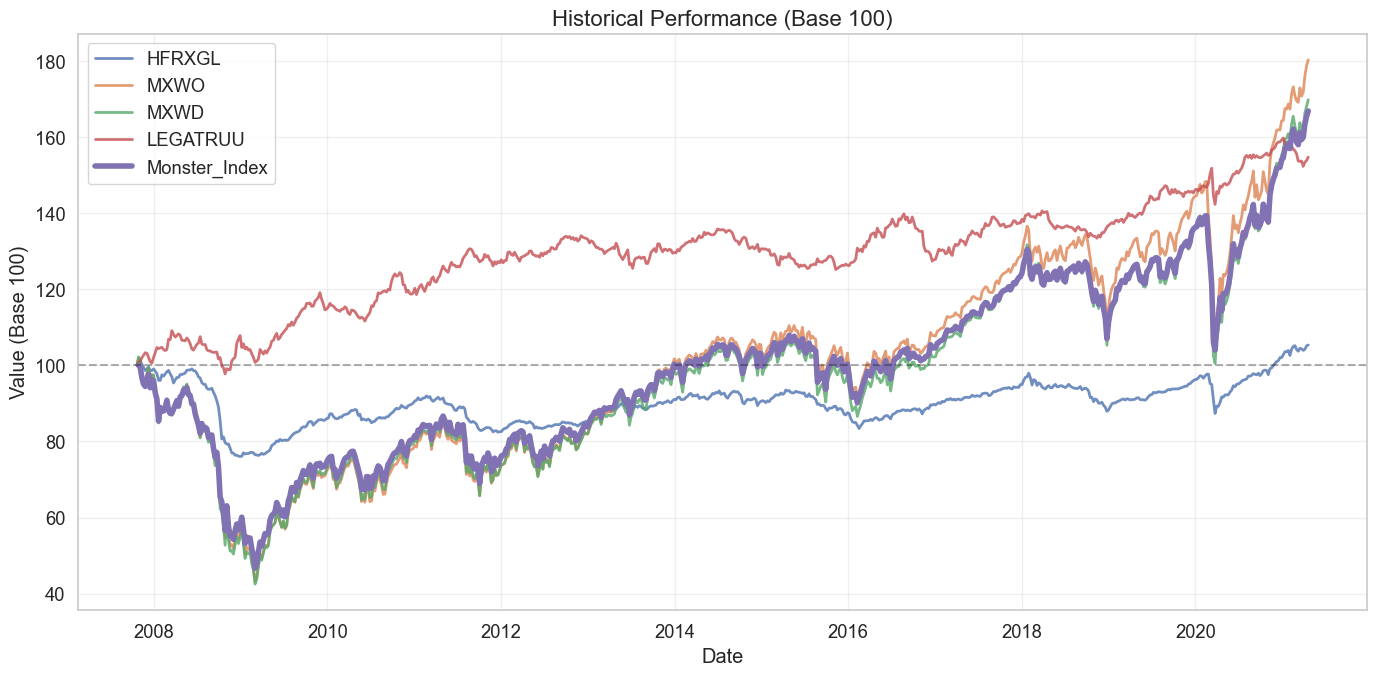

In [25]:
# ── 3. Target Exploration ──────────────────────────────────────────────────

plot_df = data[TARGETS[:-1]].copy()

# Convert Monster Index returns back to a price series starting at 1
monster_price = (1 + all_returns['Monster_Index']).cumprod()

plot_df['Monster_Index'] = monster_price

# 3. We highlight 'Monster_Index' to see our engineered target clearly
plot_normalized_series(plot_df, TARGETS, base=100, highlight_col='Monster_Index')

### Correlation & probability distribution analysis
Understanding the shape and the relationships between different indices helps us understanding the behavior of our ingredients and identify potential replication components.

=== Target Correlation ===


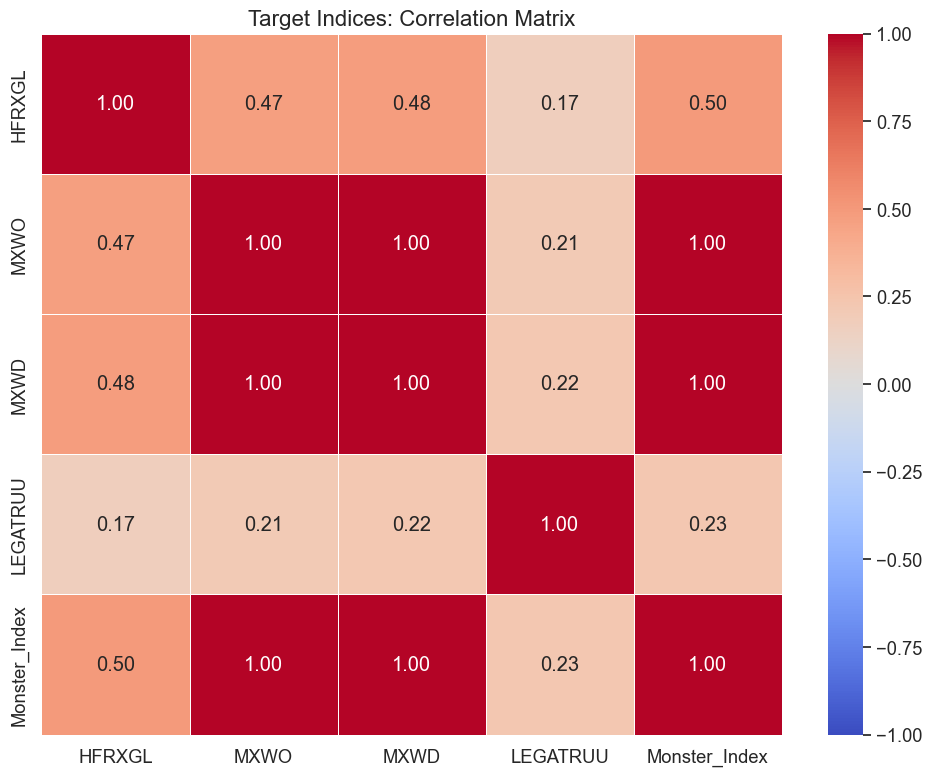


=== Return Distributions ===


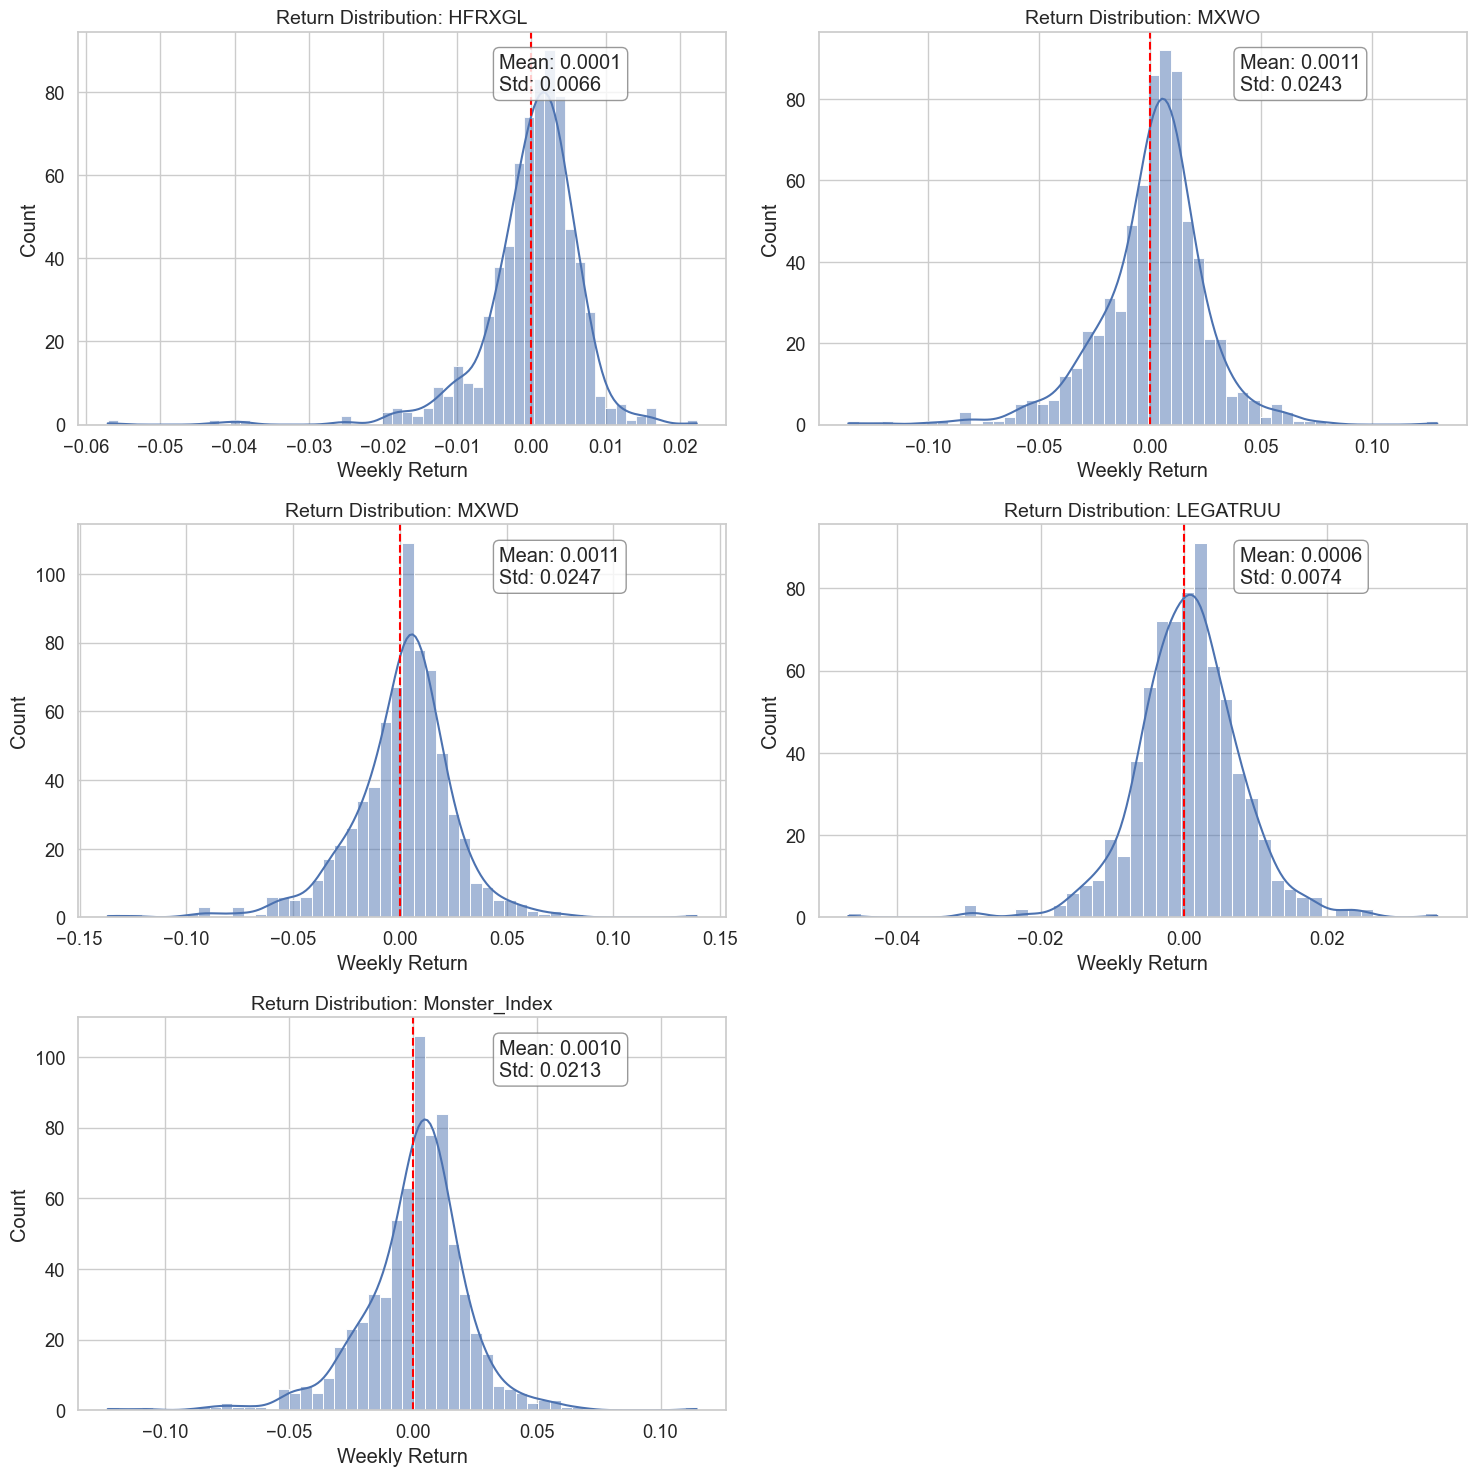


=== Rolling Correlation (vs HFRXGL) ===


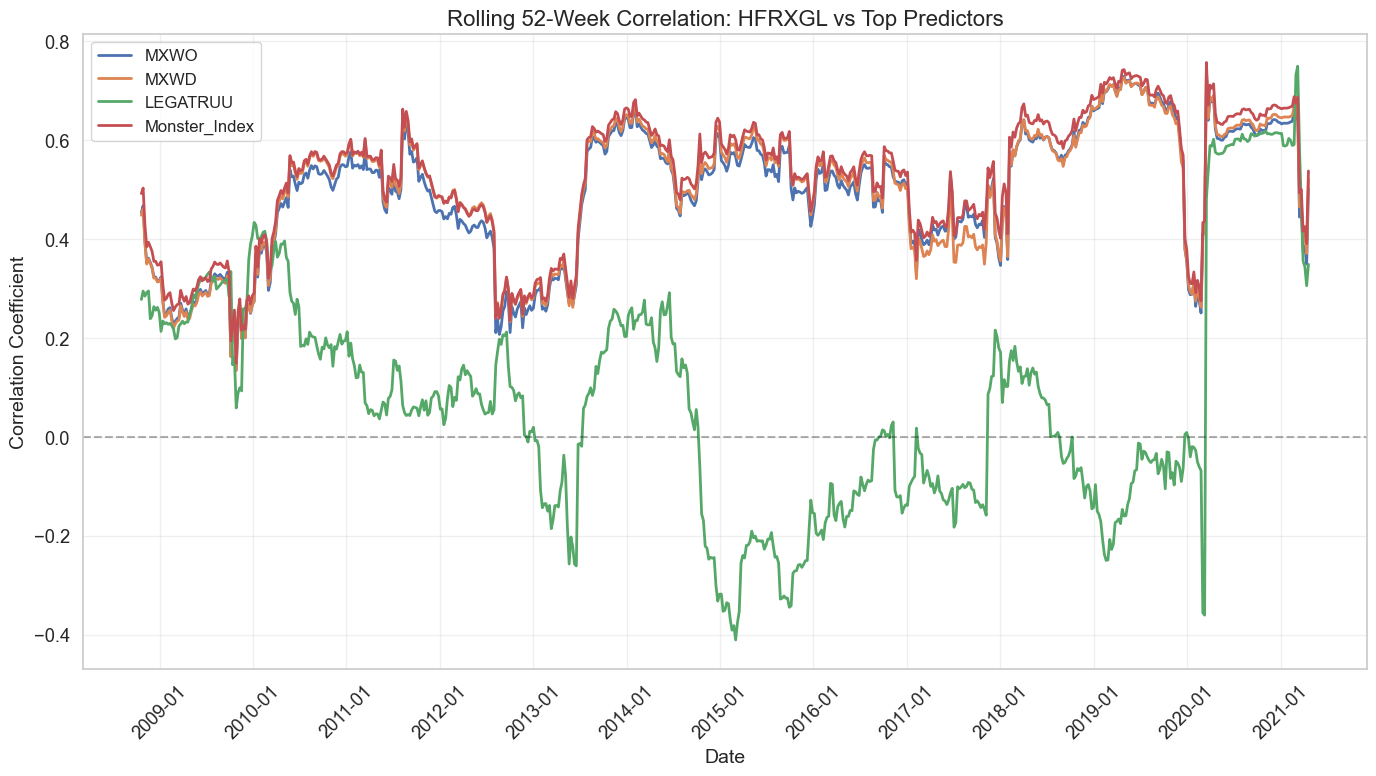

In [26]:
# ── 4. Target EDA (Exploratory Data Analysis) ──────────────────────────────
returns_targets = all_returns[TARGETS]
# 1. Static Correlation
print("=== Target Correlation ===")
plot_correlation_heatmap(returns_targets, title='Target Indices: Correlation Matrix')

# 2. Return Distributions
print("\n=== Return Distributions ===")
plot_return_distributions(returns_targets, TARGETS)


# 3. Rolling Correlation (Instability Check)
print(f"\n=== Rolling Correlation (vs {MAIN_TARGET}) ===")
compare_list = [t for t in TARGETS if t != MAIN_TARGET]

# This works perfectly for comparing indices too!
plot_rolling_correlations(returns_targets, MAIN_TARGET, compare_list, window=52)


<br>

Let's examine the statistical properties of our target indices.


=== Top Futures Correlated with HFRXGL ===


,Correlation_with_Target
ES1,0.441119
TP1,0.394622
NQ1,0.390603
VG1,0.341651
CO1,0.277859



=== Normality Check (QQ Plots) ===


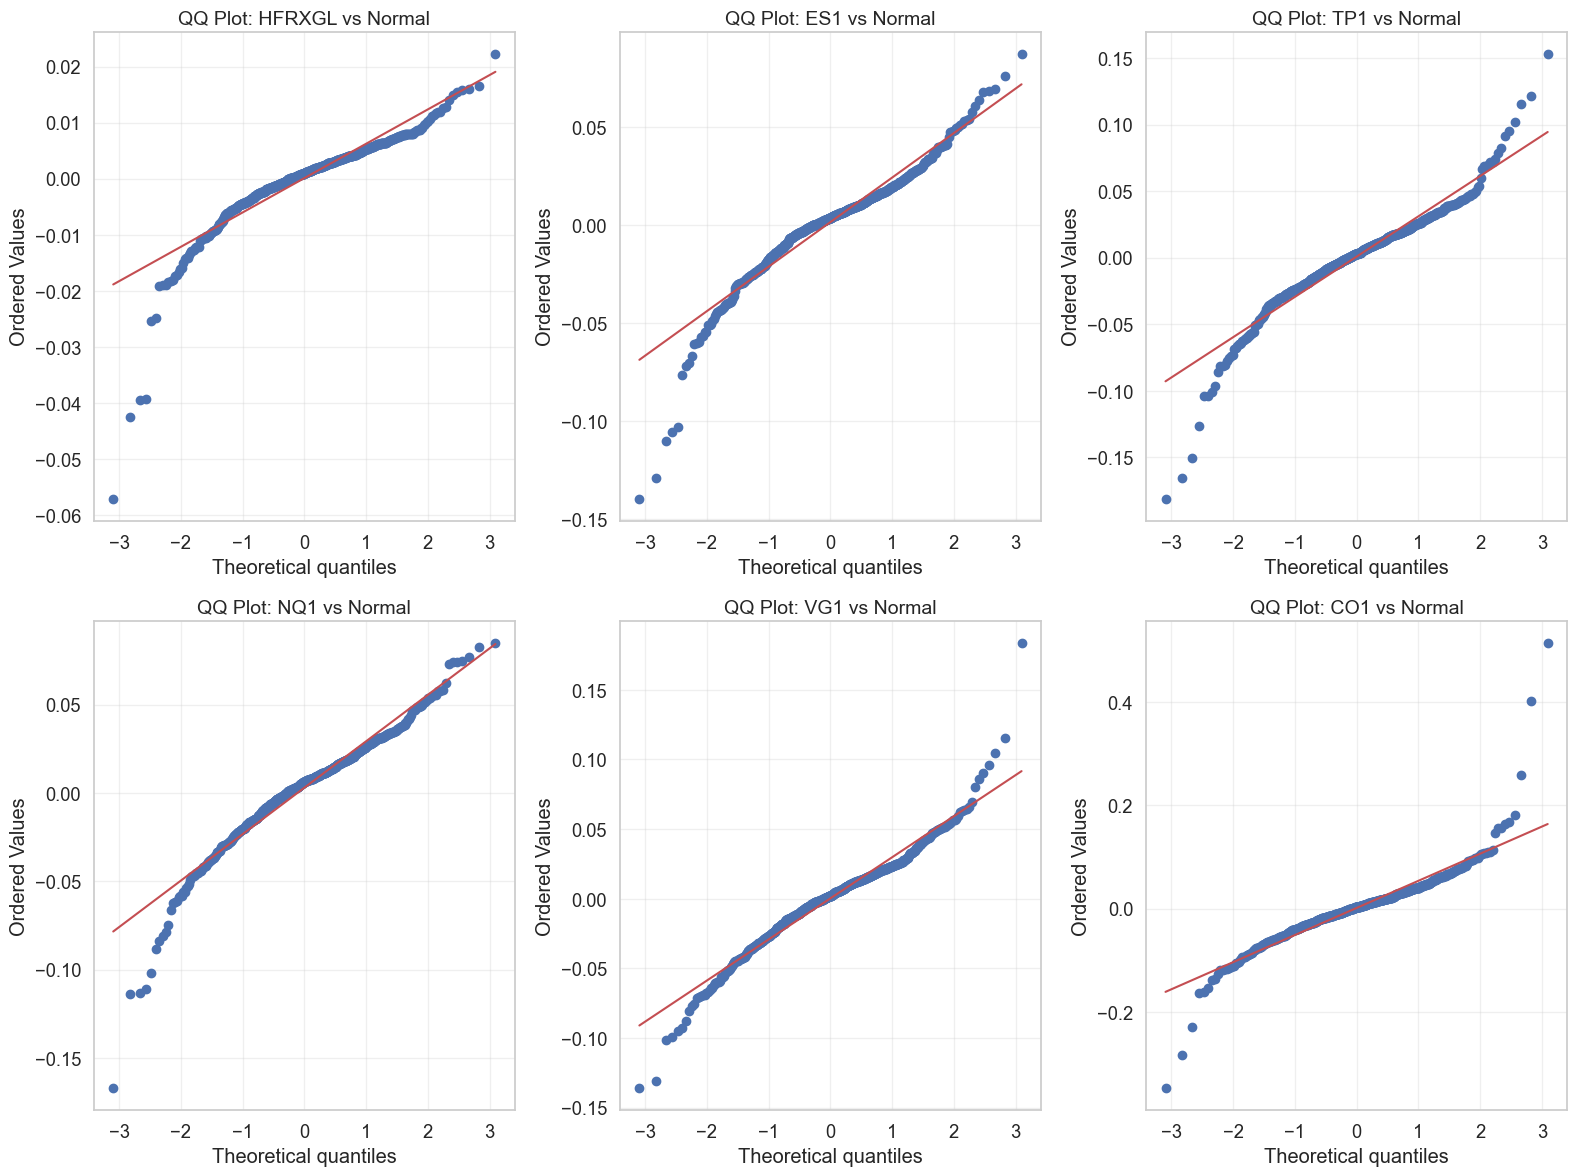

In [27]:
# ── 5. Target vs Predictors: Correlation & Normality ──────────────────────

# 1. Slice our existing Master returns dataframe
# (Assuming all_returns was already created and contains Monster_Index)
target_series = all_returns[MAIN_TARGET]
futures_series = all_returns[FUTURES]

# 2. Calculate Correlations
correlations = futures_series.corrwith(target_series).to_frame('Correlation_with_Target')

# Sort by absolute correlation to find the strongest drivers
correlations['Abs_Corr'] = correlations['Correlation_with_Target'].abs()
correlations = correlations.sort_values('Abs_Corr', ascending=False)

print(f"=== Top Futures Correlated with {MAIN_TARGET} ===")
display(correlations[['Correlation_with_Target']].head(5))

# 3. Create QQ plots using our extended 2x3 layout function
# This identifies if the "Fat Tails" we found in the target exist in the features too
print("\n=== Normality Check (QQ Plots) ===")
top_5_futures = correlations.index[:5].tolist()
plot_qq_normality_extended(target_series, futures_series, top_5_futures)

In [28]:
# Print the top correlated futures, just for reference
print("Top futures contracts by correlation with target index:")
display(correlations.head())

Top futures contracts by correlation with target index:


,Correlation_with_Target,Abs_Corr
ES1,0.441119,0.441119
TP1,0.394622,0.394622
NQ1,0.390603,0.390603
VG1,0.341651,0.341651
CO1,0.277859,0.277859


<br>

We'll analyze the **autocorrelation** properties of our target indices to understand their time series behavior. It is possible to take this into account in modelling, and in any case it is better to know what the situation is.

<br>

=== ACF & PACF Analysis (20 Lags) ===


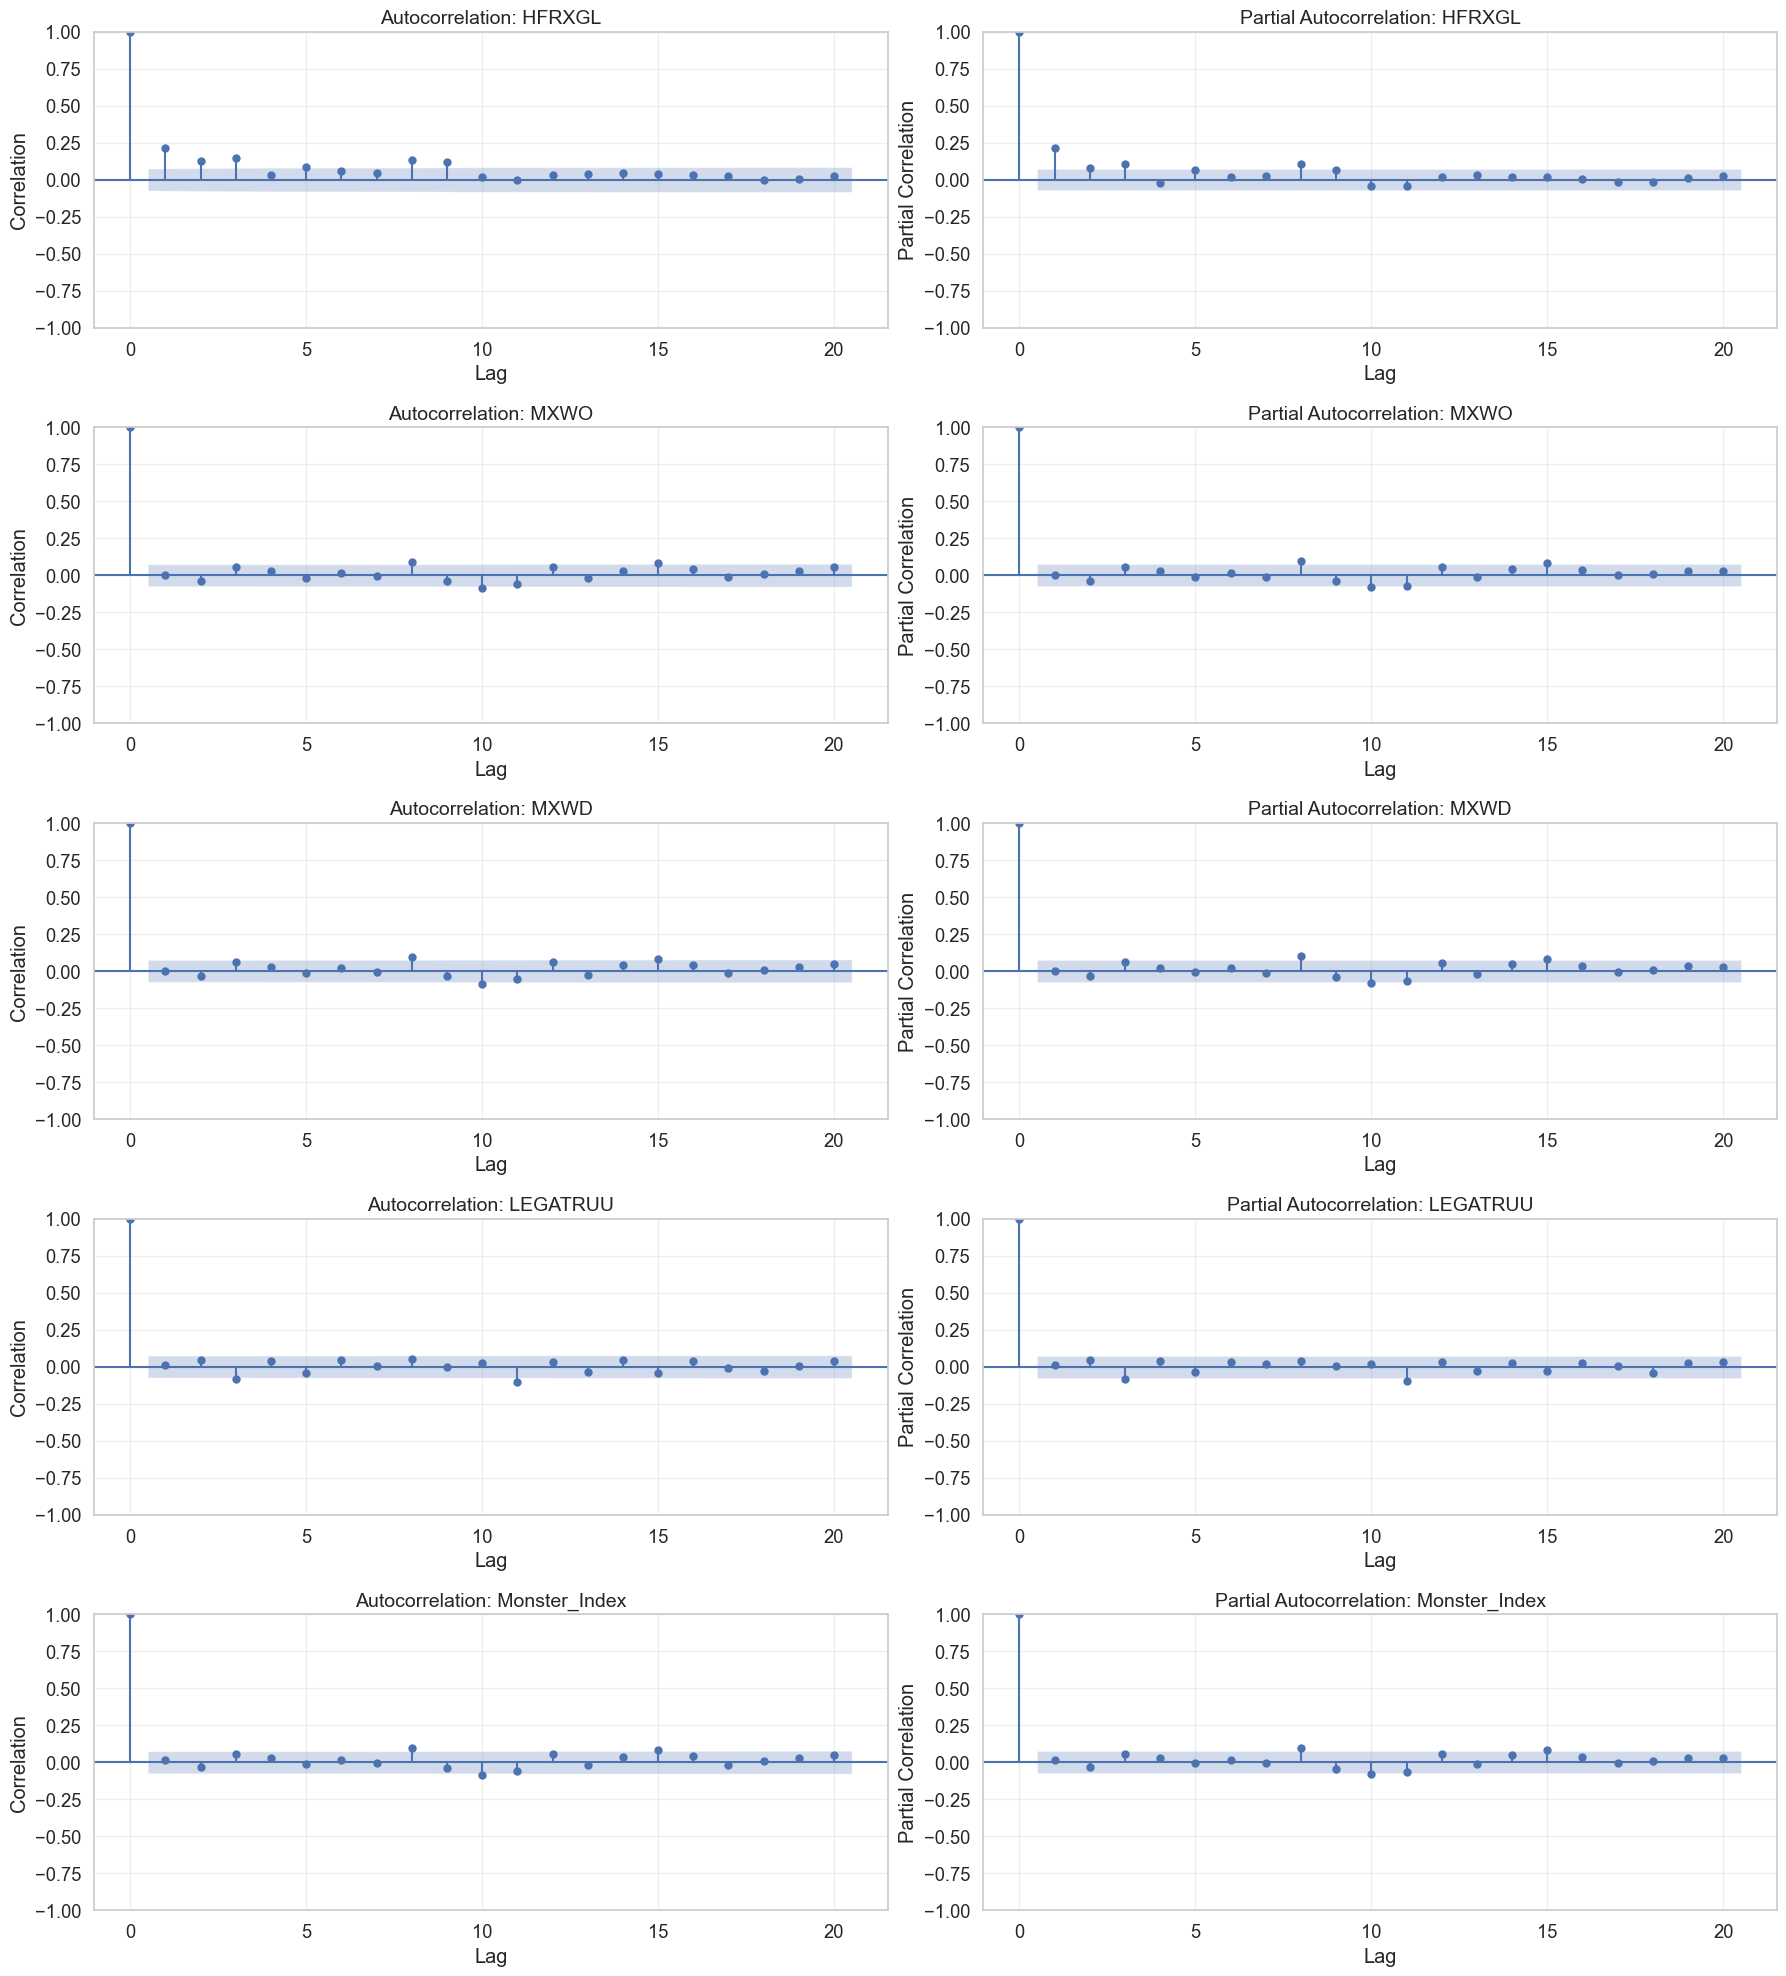

In [29]:
# ── 6. Autocorrelation Analysis ───────────────────────────────────────────
# We check for serial correlation (momentum/mean-reversion) to ensure
# independent observations

max_lags = 20
print(f"=== ACF & PACF Analysis ({max_lags} Lags) ===")
plot_acf_pacf(all_returns, TARGETS, max_lags=max_lags)

Some **statistical tests for Autocorrelation**:
Let's perform formal statistical tests to check for autocorrelation in our return series.

In [30]:
# ── 7. Quantitative Autocorrelation Test (Ljung-Box) ──────────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox

print("=== Ljung-Box Test p-values (H0: No Autocorrelation) ===")
print("Note: Values < 0.05 (in red) indicate significant autocorrelation (reject H0).\n")

lags_to_test = [5, 10, 15, 20]
lb_results = {}

# Run the test for each target in our clean universe
for col in TARGETS:
    if col in all_returns.columns:
        # return_df=True ensures consistent DataFrame output across statsmodels versions
        lb_test = acorr_ljungbox(all_returns[col], lags=lags_to_test, return_df=True)

        # Extract just the p-values mapped to their lag
        lb_results[col] = {f"Lag {lag}": lb_test.loc[lag, 'lb_pvalue'] for lag in lags_to_test}

# Convert dictionary to a clean DataFrame (Rows = Targets, Columns = Lags)
lb_df = pd.DataFrame(lb_results).T

try:
    styled_df = lb_df.style.format("{:.4f}").map(highlight_significant)
except AttributeError:
    styled_df = lb_df.style.format("{:.4f}").applymap(highlight_significant)

display(styled_df)

=== Ljung-Box Test p-values (H0: No Autocorrelation) ===
Note: Values < 0.05 (in red) indicate significant autocorrelation (reject H0).



,Lag 5,Lag 10,Lag 15,Lag 20
HFRXGL,0.0000,0.0000,0.0000,0.0000
MXWO,0.5905,0.0910,0.0258,0.0521
MXWD,0.5393,0.0653,0.0188,0.0432
LEGATRUU,0.1364,0.3071,0.0681,0.1484
Monster_Index,0.6044,0.0907,0.0269,0.0508


<br>

**Volatility Clustering Analysis**: Financial returns often exhibit volatility clustering - periods of high volatility tend to be followed by similar high volatility periods. We'll examine this phenomenon: as before, it is possible to take this into account in the modelling, and in any case it is better to know what the situation is.

<br>

=== Volatility Clustering Analysis (20 Lags) ===


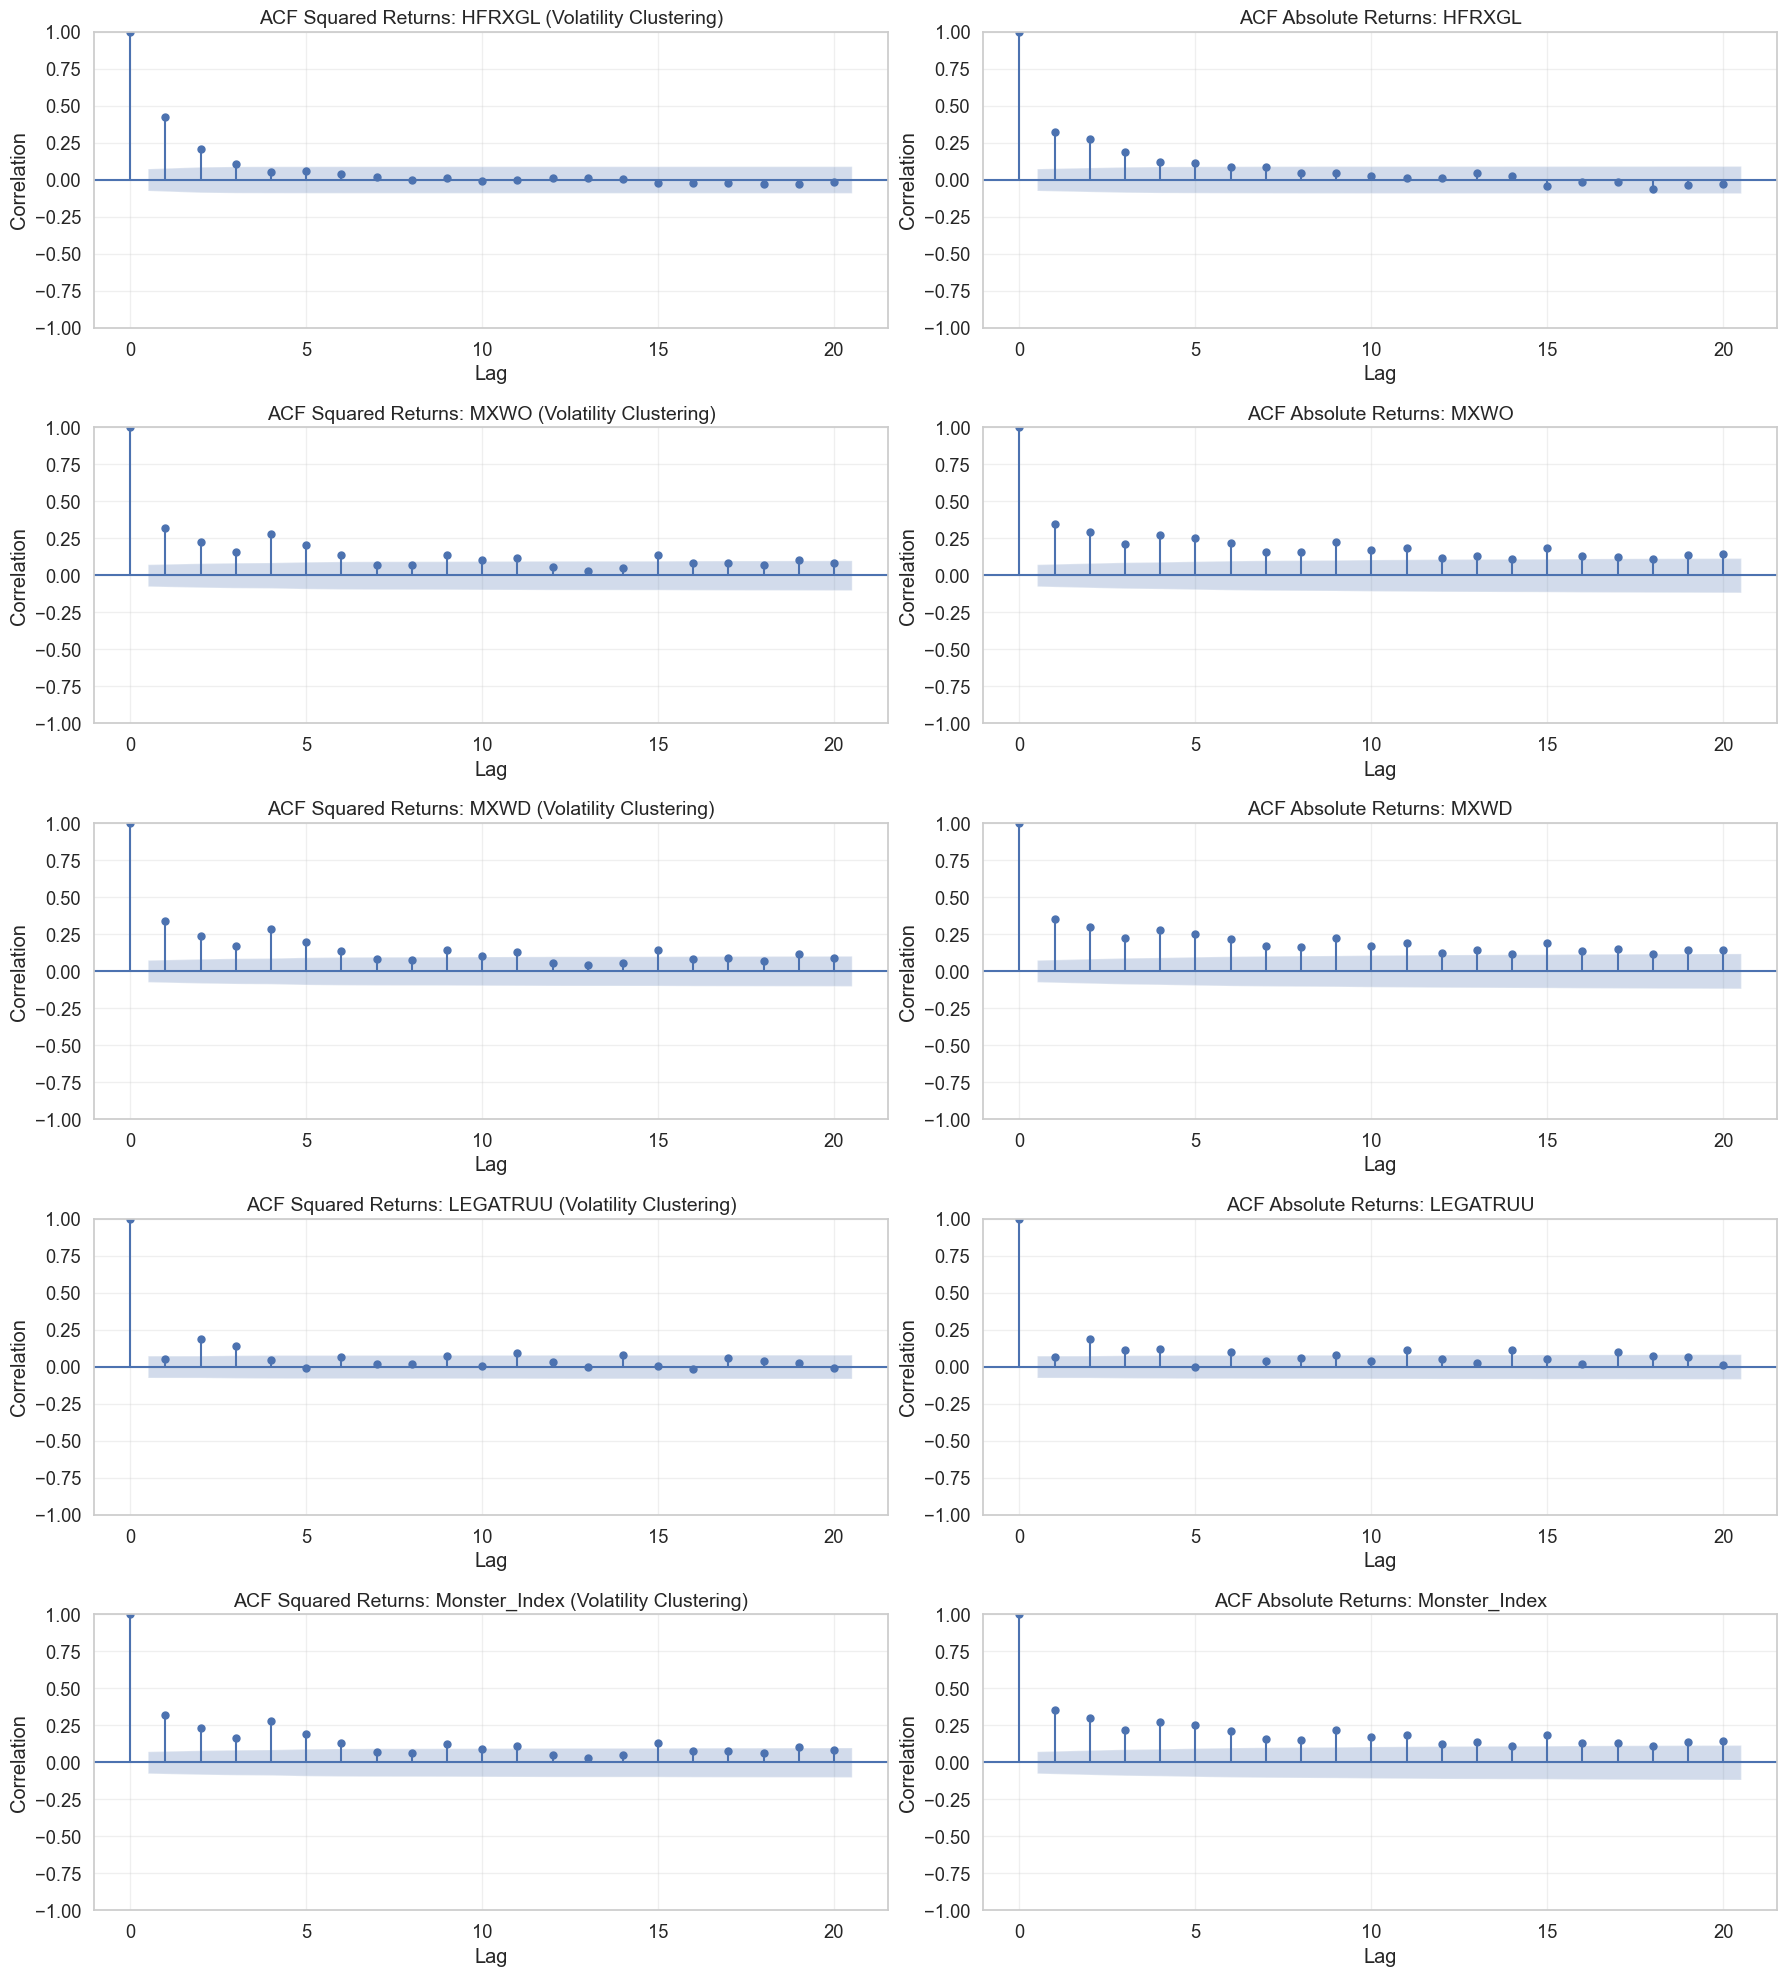

In [31]:
# ── 8. Volatility Clustering Analysis ─────────────────────────────────────
# We check the autocorrelation of squared and absolute returns.
# Significant spikes here indicate volatility clustering (ARCH/GARCH effects),
# meaning high-volatility weeks tend to follow high-volatility weeks.

max_lags = 20
print(f"=== Volatility Clustering Analysis ({max_lags} Lags) ===")

# Pass the full TARGETS list to see how different asset classes behave
plot_volatility_clustering(all_returns, TARGETS, max_lags=max_lags)

<br>

Now let's analyze our constructed target index, the Monster Index, and Futures contracts that are candidates to replicate it in more detail to understand its characteristics before attempting replication.

<br>

=== Rolling Correlation (52-Week Window) ===


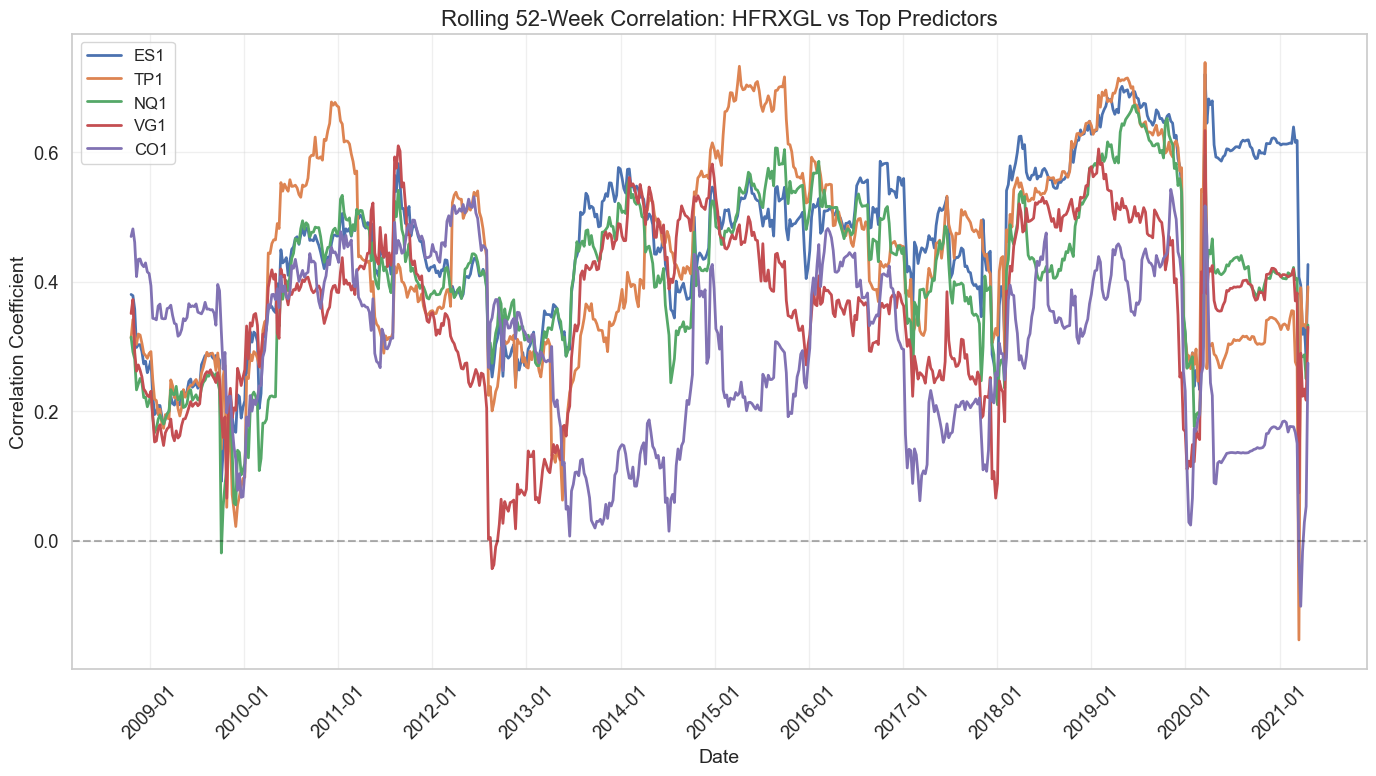

In [32]:
# ── 9. Rolling Correlation Analysis (Parameter Stability) ─────────────────
# We check if the correlations between our target and predictors are stable
# over time. Highly volatile correlations can break static regression models.

rolling_window = 52  # 52 weeks ≈ 1 year
print(f"=== Rolling Correlation ({rolling_window}-Week Window) ===")

# Pass our combined returns dataframe, the target, and the top 5 list
plot_rolling_correlations(all_returns, MAIN_TARGET, top_5_futures, window=rolling_window)

If you look at the time series and their correlations with the target, they have heterogeneous paths, so it's intuitive that they can be of help, if we want to replicate complex assets, such as our "Monster Index".

In [33]:
# ── 10. Multi-Target Performance Comparison ────────────────────────────────
# We compare the statistical signatures of our targets.
# Weekly vs. Monthly views reveal the "Smoothing Effect" found in EDA.

# 1. Select the targets we want to compare (usually HFRXGL and Monster)
comparison_targets = [MAIN_TARGET, 'Monster_Index']
all_stats = []

for t in comparison_targets:
    t_returns = all_returns[t]

    # Weekly view
    wk_stats = get_comprehensive_stats(t_returns, freq='W')
    wk_stats.name = (t, 'Weekly')

    # Monthly view
    mo_returns = t_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
    mo_stats = get_comprehensive_stats(mo_returns, freq='M')
    mo_stats.name = (t, 'Monthly')

    all_stats.extend([wk_stats, mo_stats])

# 2. Create Multi-Index DataFrame
stats_df = pd.concat(all_stats, axis=1)
stats_df.columns = pd.MultiIndex.from_tuples(stats_df.columns)

# Custom formatting application
formatted_stats = stats_df.apply(lambda row:
    row.map(lambda x: f"{x*100:.2f}%") if row.name in ['Annualized Return', 'Annualized Volatility', 'Max Drawdown']
    else row.map(lambda x: f"{x:.2f}"), axis=1)

print("=== Final Target Baseline Comparison ===")
display(formatted_stats)

=== Final Target Baseline Comparison ===


HFRXGL          Monster_Index         
                        Weekly  Monthly        Weekly  Monthly
Annualized Return        0.50%    0.57%         5.11%    5.18%
Annualized Volatility    4.78%    6.09%        15.37%   15.65%
Sharpe Ratio              0.10     0.09          0.33     0.33
Max Drawdown           -24.91%  -24.70%       -53.32%  -49.82%
Skewness                 -2.30    -2.50         -0.71    -1.43
Kurtosis                 13.70    10.81          4.63     4.79

=== Scatter Plot Matrix: HFRXGL vs Top 5 Futures ===


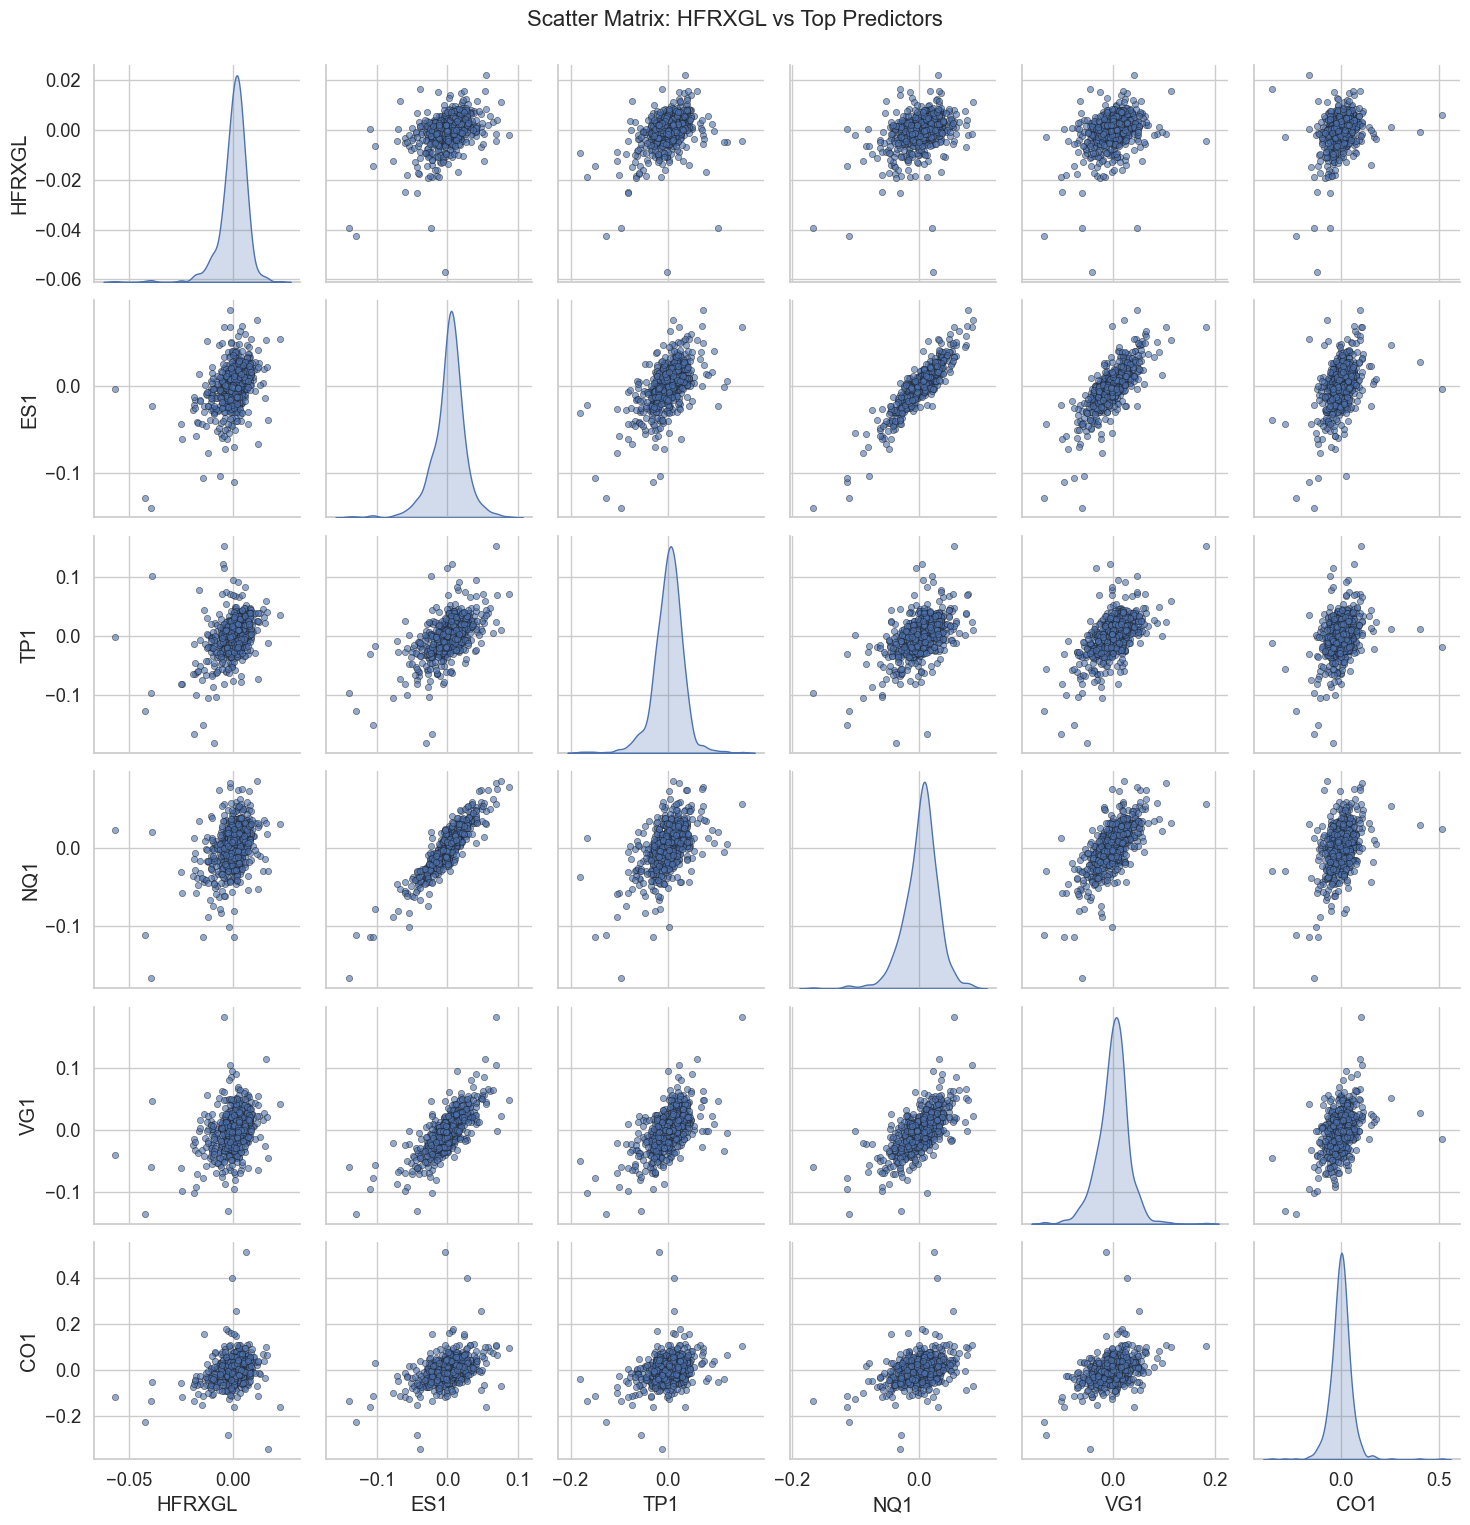

In [34]:
# ── 11. Scatter Plot Matrix (Linearity Check) ─────────────────────────────
# We visually inspect the relationships between our target and top predictors
# to ensure they are roughly linear (a core assumption of Lasso regression)
# and to spot any severe outliers.

print(f"=== Scatter Plot Matrix: {MAIN_TARGET} vs Top 5 Futures ===")

# Generate the plot using our active dataset
plot_scatter_matrix(all_returns, MAIN_TARGET, top_5_futures)

# ── 12. Fama-French 3-Factor Analysis ─────────────────────────────────────

"""
### Fama-French 3-Factor Decomposition
This analysis regresses the target's excess returns against the **Market**, **Size (SMB)**,
and **Value (HML)** factors.
* **Alpha**: Indicates "Skill" or returns not explained by these broad risk factors.
* **Beta**: Indicates the sensitivity to an arbitrary index adapted to the security with respect to which you measure the volatility to.
* **R-Squared**: Shows how much of the target's behavior is simply "disguised" equity beta.


In [35]:
# ── 12. Fama-French 3-Factor Analysis ─────────────────────────────────────
# We regress the target excess returns against the Fama-French factors
# (Market Risk Premium, Size, Value) to determine if the target generates
# true Alpha, or if its returns are just disguised equity beta.

print(f"=== Fama-French 3-Factor Decomposition for {MAIN_TARGET} ===")

try:
    # 1. Fetch Fama-French data using the helper function
    ff_data = get_fama_french_data()

    # 2. Prepare our local target data
    target_returns = all_returns[MAIN_TARGET]
    monthly_target = target_returns.resample('ME').apply(lambda x: (1 + x).prod() - 1)
    monthly_target.name = MAIN_TARGET
    monthly_target.index = monthly_target.index.to_period('M')

    # 3. Align and Merge
    common_dates = monthly_target.index.intersection(ff_data.index)
    if len(common_dates) == 0:
        raise ValueError("Error: No common dates found between local file and web data.")

    ff_merged = pd.concat([monthly_target.loc[common_dates], ff_data.loc[common_dates]], axis=1)

    # 4. OLS Regression Setup
    # Target (y): excess return (Target - Risk-Free Rate)
    y = ff_merged[MAIN_TARGET] - ff_merged['RF']

    # Predictors (X): Fama-French Factors + Constant for Alpha
    X = ff_merged[['Mkt-RF', 'SMB', 'HML']]
    X = sm.add_constant(X)

    ff_model = sm.OLS(y, X).fit()

    # 5. Display Results
    results_df = pd.DataFrame({
        'Coefficient': ff_model.params,
        'Std Error': ff_model.bse,
        't-Stat': ff_model.tvalues,
        'P-Value': ff_model.pvalues
    })

    def highlight_pvals(val):
        color = '#d62728' if val < 0.05 else 'inherit'
        return f'color: {color}; font-weight: {"bold" if val < 0.05 else "normal"}'

    print("\nRegression Coefficients:")
    results_df.rename(index={'const': 'Alpha (Skill)'}, inplace=True)
    display(results_df.style.format('{:.4f}').map(highlight_pvals, subset=['P-Value']))

    print("\nModel Reliability:")
    rsquared_df = pd.DataFrame({
        'Metric': ['R-squared', 'Adjusted R-squared'],
        'Value': [ff_model.rsquared, ff_model.rsquared_adj]
    })
    display(rsquared_df.style.format({'Value': '{:.4f}'}))

except Exception as e:
    print("Error during Fama-French analysis:")
    print(traceback.format_exc())

=== Fama-French 3-Factor Decomposition for HFRXGL ===

Regression Coefficients:


,Coefficient,Std Error,t-Stat,P-Value
Alpha (Skill),-0.0025,0.0011,-2.3589,0.0195
Mkt-RF,0.2576,0.0240,10.7151,0.0000
SMB,0.0235,0.0453,0.5187,0.6047
HML,-0.0415,0.0357,-1.1623,0.2469



Model Reliability:


,Metric,Value
0,R-squared,0.4626
1,Adjusted R-squared,0.4524


In [36]:
# Save the cleaned data so the Modelling notebook can use it
all_returns.to_pickle("all_returns_data.pkl")

# Black and Litterman

We use Black and Litterman to create a Monster Portfolio. This will help us to model the best performing monster index.
For Market capitalizations vector we are going to use the official data:
- MXWO : https://tinyurl.com/48d25mur -> 148.44 Billion NAV
- MXWD : https://finance.yahoo.com/quote/XWD.TO/ -> 117.09 Billion NAV
- LEGATRUU : https://tinyurl.com/m964pp3a -> 14.24 Billion NAV
- HFRXGL : https://it.finance.yahoo.com/quote/DBMF/ -> currently the largest : 30.47 Billion NAV

In [37]:
import numpy as np
import pandas as pd
from scipy.linalg import inv

# 1. Isolate ALL 4 targets & compute Covariance
tickers = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
ret_data = all_returns[tickers].dropna()
cov_mat = ret_data.cov()

# 2. Market Prior based EXACTLY on your ETF NAVs (Total $310.24B)
bench_prop = pd.Series([0.4785, 0.3774, 0.0459, 0.0982], index=tickers)
t_bill_r = 0.0  # Assuming 0 for simple weekly excess returns

# 3. Compute Implied Market Returns (The Baseline Anchor)
bench_ret = 0.06 / 52 
norm_fact = (bench_ret - t_bill_r) / np.dot(np.dot(bench_prop, cov_mat), bench_prop)
exp_ret = np.dot(cov_mat, bench_prop) * norm_fact + t_bill_r

# 4. Inject Your Views (Deltas) - Now with 4 inputs
# Example: Bullish on MXWO, Bearish on Bonds, Neutral on MXWD and Hedge Funds
delta_port = pd.Series([0.000, 0.000, 0.000, 0.000], index=tickers)

# The Black-Litterman Tracking Matrix
track_mat = cov_mat / np.diag(cov_mat)

# 5. Calculate View-Adjusted Returns
opn_adj_ret = exp_ret + np.dot(track_mat, delta_port)

# 6. Calculate Final Optimal Weights
bl_weights = np.dot(inv(cov_mat), (opn_adj_ret - t_bill_r))
bl_weights = bl_weights / np.sum(bl_weights) # Normalize to 100%

print("=== Black-Litterman Target Weights (4 Assets) ===")
print(pd.Series(bl_weights, index=tickers).round(4).to_frame("Weight"))

# 7. Create the Super Portfolio!
all_returns['BL_SUPER_PORTFOLIO'] = ret_data.dot(bl_weights)

=== Black-Litterman Target Weights (4 Assets) ===
          Weight
MXWO      0.4785
MXWD      0.3774
LEGATRUU  0.0459
HFRXGL    0.0982
